In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import importlib
import collision
importlib.reload(collision)
from collision import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights

# parameters
e_mass = 5.48579909e-4     # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

In [3]:
# define properties of molecules
reduced_masses = {"NaKNaK" : 62 / 2, "RbKRb" : 87 * (87 + 40) / (87 + 87 + 40)}     # amu
van_der_wall_coeffs = {"NaKNaK" : 561070, "RbKRb" : 8000}      # a.u.

molecules = "NaKNaK"
mu = reduced_masses[molecules] / e_mass      # now in a.u.
c6 = van_der_wall_coeffs[molecules]          # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 2 * np.pi / E_beta    # time
print("reduced mass", mu)
print("C6", c6)
print("beta (a0)", beta)
print("E_beta (K)", E_beta * t0)
print("tau_beta (s)", tau_beta * tau0)

reduced mass 56509.54307916515
C6 561070
beta (a0) 501.8133487679625
E_beta (K) 1.1095363445288911e-05
tau_beta (s) 4.325448841671024e-06


In [4]:
num_samples = 500

# properties of resonant spectrum
mean_spacing = 10.0
mean_x = 0.1
num_resonances = 400       # should be odd
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

# thermal properties
threshold_energy = 0.1
temp = 0.5
num_energies = 2000

C:\Users\kevin\AppData\Local\Temp\ipykernel_44304\173395770.py:5: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  time_delay = sc.integrate.quad(f, 0, 10 * temp)[0]
C:\Users\kevin\AppData\Local\Temp\ipykernel_44304\173395770.py:5: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  time_delay = sc.integrate.quad(f, 0, 10 * temp)[0]


Fraction Positive:  0.1862


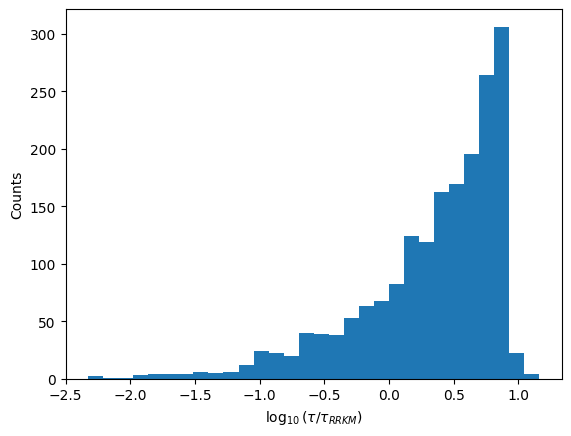

In [5]:
time_delays = []
for i in range(10000):
    energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
    f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
    time_delay = sc.integrate.quad(f, 0, 10 * temp)[0]
    time_delays.append(time_delay)

positive = [delay for delay in time_delays if delay > 0]
frac_positive = len(positive) / len(time_delays) 
print("Fraction Positive: ", frac_positive)

normalized = (mean_spacing / 2 / np.pi) * np.array(positive)
mean_delay = np.mean(normalized)
std_delay = np.std(normalized)

log_delay = np.log10(normalized)
plt.hist(log_delay, bins=30)
plt.xlabel(f"$\\log_{{10}} (\\tau / \\tau_{{RRKM}})$")
plt.ylabel("Counts")
plt.show()


C:\Users\kevin\AppData\Local\Temp\ipykernel_44304\1512995715.py:6: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  if (mean_spacing / 2 / np.pi) * sc.integrate.quad(f, 0, 10 * temp)[0] > 1:
C:\Users\kevin\AppData\Local\Temp\ipykernel_44304\1512995715.py:6: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  if (mean_spacing / 2 / np.pi) * sc.integrate.quad(f, 0, 10 * temp)[0] > 1:
c:\Users\kevin\OneDrive\PhD\stickycollisions\collision.py:104: RuntimeWarning: divide by zero encountered in scalar divide
  beta = 1 / temp
c:\Users\kevin\OneDrive\PhD\stickyco

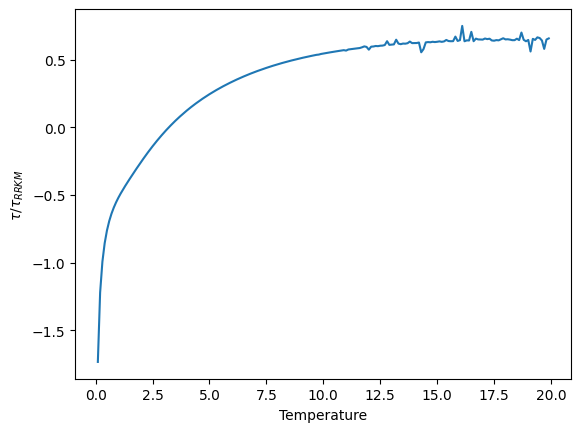

In [9]:
time_delays = []
temps = np.arange(0, 20, 0.1)
while True:
    energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
    f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
    if (mean_spacing / 2 / np.pi) * sc.integrate.quad(f, 0, 10 * temp)[0] > 1:
        break
for temp in temps:
    time_delay = sc.integrate.quad(f, 0, 10 * temp)[0]
    time_delays.append(time_delay)

normalized = (mean_spacing / 2 / np.pi) * np.array(time_delays)
mean_delay = np.mean(normalized)
std_delay = np.std(normalized)

plt.plot(temps, time_delays)
plt.ylabel(f"$\\tau / \\tau_{{RRKM}}$")
plt.xlabel("Temperature")
plt.show()


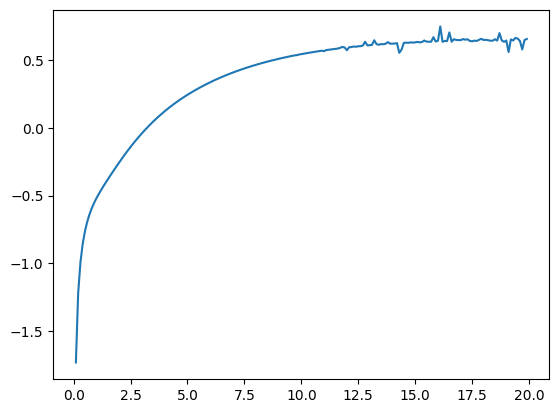

In [10]:
plt.plot(temps, time_delays)
plt.savefig("rate_vs_temp_2.pdf")